# Lecture 6

Today's Topics:

- Serialization
- Visualization
- Probability
- Confidence Intervals
- Bias Variance Tradeoff

## Linear Regression

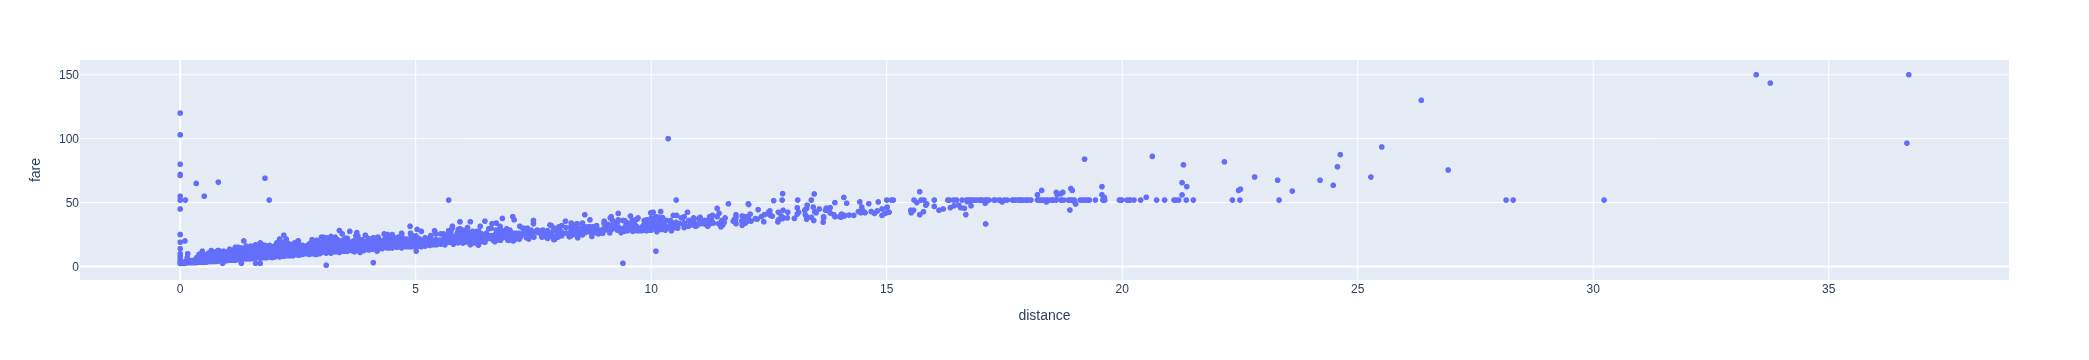

In [ ]:
import plotly.express as px

px.scatter(df, x='distance', y='fare')

A regression analysis determines the relationships between a dependent variable (often called $Y$) and an independent variable(s) (often called $X$).

The results are often used for prediction, as it is the simplest example of supervised machine learning.

We will start with linear regression.

Goal: find a linear relationship between the independent and dependent variables:

$$ y = mx + b $$

Score each line with how close the actual and predicted y-values are (using RMSE for the loss function).

The best scoring line is called the regression line.

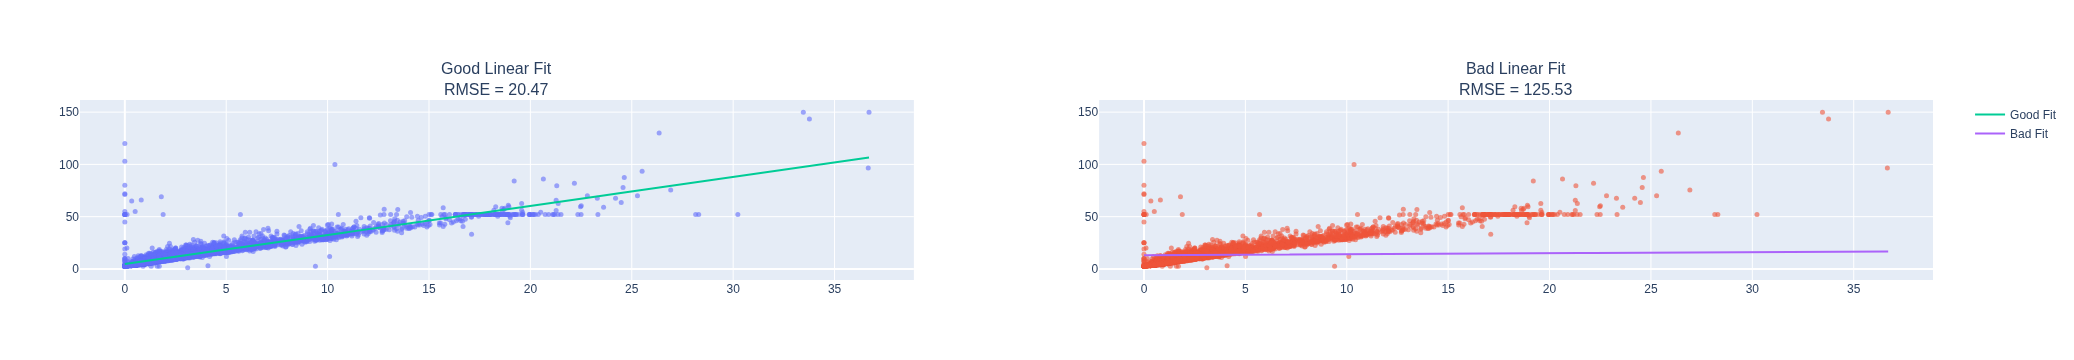

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import mean_squared_error

x = df["distance"].values
y = df["fare"].values

order = np.argsort(x)
x_sorted = x[order]
y_sorted = y[order]

# good model
coef_good = np.polyfit(x, y, 1)
y_pred_good = np.polyval(coef_good, x_sorted)
rmse_good = mean_squared_error(y, np.polyval(coef_good, x))

# bad model
coef_bad = [0.1, np.mean(y)] 
y_pred_bad = coef_bad[0] * x_sorted + coef_bad[1]
rmse_bad = mean_squared_error(y, coef_bad[0] * x + coef_bad[1])

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        f"Good Linear Fit<br>RMSE = {rmse_good:.2f}",
        f"Bad Linear Fit<br>RMSE = {rmse_bad:.2f}",
    ]
)

for col in [1, 2]:
    fig.add_trace(
        go.Scatter(
            x=x, y=y,
            mode="markers",
            marker=dict(size=5, opacity=0.6),
            showlegend=False
        ),
        row=1, col=col
    )

fig.add_trace(go.Scatter(x=x_sorted, y=y_pred_good, mode="lines", name="Good Fit"),
              row=1, col=1)

fig.add_trace(go.Scatter(x=x_sorted, y=y_pred_bad, mode="lines", name="Bad Fit"),
              row=1, col=2)

fig.show()


The correlation coefficient gives a single number measuring the association between the variables.

Regression gives a function that computes an estimate for each input.

The differences, or residuals (red lines), can give additional information.

[Residual Plot Demo Visual](https://shiney.zoology.ubc.ca/whitlock/Residuals/)

## Serializing Objects

Serialization is the act of translating data structures or objects into a format that can be stored and used later.

A standard approach is Pickling:

    - Save to a file: `pickle.dump(object, file, ...)`
    - Returns a string: `pickle.dumps(object, ...)`
  
Unpickling is the deserialization of an object:

    - Read from a file: `Unpickler(file).load()` or `pickle.load(file, ...)`
    - Read from a string: `pickle.loads(bytes_object, ...)`

In [1]:
import pickle

data = {
    'a': ['alex', 'alia'],
    'b': ['brandon', 'bri'],
    'c': ['calvin', 'carmen']
}

In [ ]:
with open('data.pickle', 'wb') as f:
    pickle.dump(data,f,pickle.HIGHEST_PROTOCOL)
    # stores data in a file called data.pickle

In [ ]:
with open('data.pickle', 'rb') as f:
    new_data = pickle.load(f)
    # reads the data in the file called data.pickle

print(new_data)

{'a': ['alex', 'alia'], 'b': ['brandon', 'bri'], 'c': ['calvin', 'carmen']}


What can be pickled and unpickled:

- `None`, `True`, `False`
- integers, floating point numbers, complex numbers
- strings, bytes, bytearrays
- tuples, lists, sets, dictionaries containing picklable objects
- functions defined at the top level of a module (def not lambda)
- built in functions defined at the top level of a module
- classes that are defined at the top level of a module

## Visualization

### Visualizing Quantitative Data: Histograms

We will use plotly and seaborn as our default for creating plots.

In [39]:
import seaborn as sns
import numpy as np
import statsmodels
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff

In [17]:
sns.set()
ti = sns.load_dataset('titanic').dropna().reset_index(drop=True)

ff.create_distplot([ti['age']], ['ages'])
#                    column      labels

We can also control how the data is divided

In [18]:
ff.create_distplot([ti['age']], ['ages'], bin_size=10)

### Visualizing Quantitative Data: Box Plots

- Box plots show where most of the data is.
- Usually use 25th and 75th percentiles of the box with "whiskers" capturing rest of data (modulo outliers).

In [20]:
px.box(x=ti['fare'])

Inter-Quartile Range (IQR) used to decide outliers.

$$ IQR = Q_3 - Q_1$$

![image](https://www.statisticshowto.com/wp-content/uploads/2012/03/iqr.jpg)

In [23]:
lower, upper = np.percentile(ti['fare'], [25,75])
IQR = upper - lower
print(f'Q1: {lower}\nQ3: {upper}\nIQR: {IQR}')

Q1: 29.7
Q3: 90.0
IQR: 60.3


Can display box plots for different categories:

In [24]:
px.box(x=ti['fare'], y=ti['who'])

### Visualizing Quantitative Data: Scatter Plots

Scatter plots are used to compare two quantitative variables

In [32]:
px.scatter(ti,x='age',y='fare',color='who',trendline='ols')

For qualitative or categorical data, we most often use bar charts and scatter charts.

In [33]:
px.histogram(ti,x='alive')

Counting the number of survivors, refining by class:

In [36]:
px.histogram(ti,x='alive',color='class')

### Visualizing Quantative Data: Time Series

Often data is collected over a period of time.

- Pandas recognizes most time/date formats.
- Can display and summarize information across time periods.

In [40]:
# load in the dataset
mta = pd.read_csv('https://stjohn.github.io/datasci/spr23/si2020.csv')
mta.head()

,date,entries,exits
0,2020-01-01,3128,0
1,2020-01-02,13707,0
2,2020-01-03,12507,23
3,2020-01-04,265,0
4,2020-01-05,698,0


In [44]:
# compute the rolling average
mta['7DayRolling'] = mta['entries'].rolling(7).mean()

Create a line plot of entries and rolling averages:

In [46]:
fig = px.line(mta,x='date', y='entries')
fig.add_scatter(
    x=mta['date'],
    y=mta['7DayRolling'],
    mode='lines',
    name='7-Day Rolling Avg'
)

fig.show()

![image](https://upload.wikimedia.org/wikipedia/commons/4/4d/Moving_average_sine_and_polynom_with_a_larger_interval.gif)

`rolling()` is a built-in function that computes a rolling average

Other ways of summarizing information:
- `cumulativeAverage(column)`: Returns a Series with the running average of the values.
- `cyclicAverage(column)`: Assumes data is cyclic, and computes average of points in the cycle. Since ridership is highly dependent on the day of the week, this averages the values of the same day in past weeks.
- `exponentialSmoothing(column)`: Returns a Series with a weighted average of the previous values with the most recent values have higher weight and the older ones have lower weights. The value for the first entry, `newCol[0]` is `column[0]`. The value for subsequent entries is `newCol[t+1]` = `0.5*column[t+1]` + `0.5*newCol[t]`.

## Bias-Variance Tradeoff

Tradeoff in choosing models:

- Model Bias: Too simple to represent the underlying data generation process

- Model Variance: Complex but fits the noise in the data rather than the data’s overall pattern.

To reduce bias:
- Choose a more complicated model
- Add more features

To reduce variance:
- Simplify the model
- Add more data

$$
\begin{aligned}
MSE &= \mathbb{E}\big[(\hat{f}(x) - f(x))^2\big]\\ 
&= \mathbb{E}\big[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)] + \mathbb{E}[\hat{f}(x)] - f(x))^2\big] \\
&= \mathbb{E}\big[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\big] 
+ (\mathbb{E}[\hat{f}(x)] - f(x))^2 \\
&\quad + 2\,\mathbb{E}\big[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])(\mathbb{E}[\hat{f}(x)] - f(x))\big] \\
&= \underbrace{\mathrm{Var}[\hat{f}(x)]}_{\text{variance}} 
+ \underbrace{(\mathrm{Bias}[\hat{f}(x)])^2}_{\text{bias}^2} 
+ \underbrace{\sigma^2}_{\text{irreducible error}}
\end{aligned}
$$

Even in the most perfect model, we will need to balance some form of bias and variance to find the local minima.

![image](https://www.tutorialspoint.com/machine_learning/images/bias_variance_tradeoff.jpg)

In [ ]:
import numpy as np
import plotly.graph_objects as go
from numpy.polynomial.polynomial import Polynomial

np.random.seed(0)
x = np.linspace(0, 10, 20)
y_true = np.sin(x)
y = y_true + np.random.normal(0, 0.3, size=x.shape)

degrees = list(range(1, 15))

fits = []
x_fit = np.linspace(0, 10, 200)
for d in degrees:
    coeffs = np.polyfit(x, y, d)
    y_fit = np.polyval(coeffs, x_fit)
    fits.append(y_fit)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='markers',
    name='Data',
    marker=dict(color='black', size=8)
))

fig.add_trace(go.Scatter(
    x=x_fit, y=fits[0],
    mode='lines',
    name=f'Best fit',
    line=dict(color='blue')
))

steps = []
for i, d in enumerate(degrees):
    step = dict(
        method='update',
        args=[{
            'y':[y, fits[i]],
        },
        {'annotations':[dict(
            x=5, y=1.5, text=f"Polynomial Degree: {d}", showarrow=False,
            font=dict(size=16)
        )]}],
        label=str(d)
    )
    steps.append(step)

sliders = [dict(
    active=0,
    currentvalue={"prefix": "Polynomial Degree: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders,
    annotations=[dict(
        x=5, y=1.5, text=f"Polynomial Degree: {degrees[0]}", showarrow=False,
        font=dict(size=16)
    )]
)

fig.show()

![image](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*JZbxrdzabrT33Yl-LrmShw.png)